In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Student score prediction

In [2]:
print('train data info:')

data1=pd.read_csv('./train.csv')
df1=data1.copy()

print(df1.info(),'\n\n')
print(df1.describe(),'\n\n')


print('test data info:')

data2=pd.read_csv('./test.csv')
df2=data2.copy()

print(df2.info(),'\n\n')
print(df2.describe())




train data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          1530 non-null   int64  
 1   Age                1530 non-null   int64  
 2   Gender             1530 non-null   int64  
 3   Ethnicity          1530 non-null   object 
 4   ParentalEducation  1388 non-null   object 
 5   StudyTimeWeekly    1530 non-null   float64
 6   Absences           1530 non-null   int64  
 7   Tutoring           1530 non-null   int64  
 8   ParentalSupport    1398 non-null   object 
 9   Extracurricular    1530 non-null   int64  
 10  Sports             1530 non-null   int64  
 11  Music              1530 non-null   int64  
 12  Volunteering       1530 non-null   int64  
 13  GPA                1530 non-null   float64
dtypes: float64(2), int64(9), object(3)
memory usage: 167.5+ KB
None 


         StudentID          Age     

In [3]:
#drop StudentID column
df1.drop('StudentID',axis=1,inplace=True)

df2.drop('StudentID',axis=1,inplace=True)


In [4]:
df1.head()
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1530 non-null   int64  
 1   Gender             1530 non-null   int64  
 2   Ethnicity          1530 non-null   object 
 3   ParentalEducation  1388 non-null   object 
 4   StudyTimeWeekly    1530 non-null   float64
 5   Absences           1530 non-null   int64  
 6   Tutoring           1530 non-null   int64  
 7   ParentalSupport    1398 non-null   object 
 8   Extracurricular    1530 non-null   int64  
 9   Sports             1530 non-null   int64  
 10  Music              1530 non-null   int64  
 11  Volunteering       1530 non-null   int64  
 12  GPA                1530 non-null   float64
dtypes: float64(2), int64(8), object(3)
memory usage: 155.5+ KB


In [5]:
# prepare inputs 
train_input=df1.loc[:,'Age':'Volunteering']

train_input.head()
train_input.info()


test_input=df2.loc[:,'Age':'Volunteering']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1530 non-null   int64  
 1   Gender             1530 non-null   int64  
 2   Ethnicity          1530 non-null   object 
 3   ParentalEducation  1388 non-null   object 
 4   StudyTimeWeekly    1530 non-null   float64
 5   Absences           1530 non-null   int64  
 6   Tutoring           1530 non-null   int64  
 7   ParentalSupport    1398 non-null   object 
 8   Extracurricular    1530 non-null   int64  
 9   Sports             1530 non-null   int64  
 10  Music              1530 non-null   int64  
 11  Volunteering       1530 non-null   int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 143.6+ KB


In [6]:
# prepare outputs
train_output=df1.loc[:,'GPA']

train_output.head()
train_output.info()

test_output=df2.loc[:,'GPA']

<class 'pandas.core.series.Series'>
RangeIndex: 1530 entries, 0 to 1529
Series name: GPA
Non-Null Count  Dtype  
--------------  -----  
1530 non-null   float64
dtypes: float64(1)
memory usage: 12.1 KB


## fill unknown cells

In [7]:
# input preprocessing

print('number of rows with unknown data in train data:')
print(train_input.isna().any(axis=1).sum())
# because the number of such rows is 261 and removing them can lead to missing a good part of data, I use other methods to handle these unkown data


print('number of rows with unknown data in test data:')
print(test_input.isna().any(axis=1).sum())

number of rows with unknown data in train data:
261
number of rows with unknown data in test data:
66


### replacing unknown data with their mode

In [8]:

print('columns with unknown data in train data:')
print(train_input.isnull().sum())

# I use mode metric to fill ParentalEducation and ParentalSupport cells in each row
print('\nParentalEducation mode:',train_input['ParentalEducation'].mode()[0])
train_input['ParentalEducation'].fillna(train_input['ParentalEducation'].mode()[0],inplace=True)

print('ParentalSupport mode:',train_input['ParentalSupport'].mode()[0])
train_input['ParentalSupport'].fillna(train_input['ParentalSupport'].mode()[0],inplace=True)

print('\nolumns with unknown data after preprocessing:')
print(train_input.isnull().sum())





print('columns with unknown data in test data:')
print(test_input.isnull().sum())

# I use mode metric to fill ParentalEducation and ParentalSupport cells in each row
print('\nParentalEducation mode:',test_input['ParentalEducation'].mode()[0])
test_input['ParentalEducation'].fillna(test_input['ParentalEducation'].mode()[0],inplace=True)

print('ParentalSupport mode:',test_input['ParentalSupport'].mode()[0])
test_input['ParentalSupport'].fillna(test_input['ParentalSupport'].mode()[0],inplace=True)

print('\nolumns with unknown data after preprocessing:')
print(test_input.isnull().sum())


columns with unknown data in train data:
Age                    0
Gender                 0
Ethnicity              0
ParentalEducation    142
StudyTimeWeekly        0
Absences               0
Tutoring               0
ParentalSupport      132
Extracurricular        0
Sports                 0
Music                  0
Volunteering           0
dtype: int64

ParentalEducation mode: Some College
ParentalSupport mode: Moderate

olumns with unknown data after preprocessing:
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
dtype: int64
columns with unknown data in test data:
Age                   0
Gender                0
Ethnicity             0
ParentalEducation    40
StudyTimeWeekly       0
Absences              0
Tutoring              0
ParentalSupport      30
Extracurr

/tmp/ipykernel_10463/1785428202.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_input['ParentalEducation'].fillna(train_input['ParentalEducation'].mode()[0],inplace=True)
/tmp/ipykernel_10463/1785428202.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

### converting categorical features to one-hot vector format


In [9]:
train_input=pd.get_dummies(train_input,columns=['Ethnicity','ParentalEducation','ParentalSupport'])

print('\ntrain_input after convering categorical features to one-hot vectors:\n\n',train_input)


test_input=pd.get_dummies(test_input,columns=['Ethnicity','ParentalEducation','ParentalSupport'])


train_input after convering categorical features to one-hot vectors:

       Age  Gender  StudyTimeWeekly  Absences  Tutoring  Extracurricular  \
0      17       1         9.906353        25         0                1   
1      18       0         4.681156        20         0                0   
2      16       0         6.845312        13         0                0   
3      18       0        19.885760         2         0                1   
4      15       1        14.806261        20         0                0   
...   ...     ...              ...       ...       ...              ...   
1525   16       1         4.708145        16         1                0   
1526   15       0         3.410608         5         0                0   
1527   17       1         4.190384        17         0                0   
1528   18       0        12.207877         1         0                0   
1529   18       0        12.304298         9         0                0   

      Sports  Music  Volunt

### normalizing numerical features (for better optimization)

In [10]:
# input preprocessing
# I normalize input numerical features and outputs(GPAs)
scaler=StandardScaler()

train_input[train_input.select_dtypes(include=['int64','float64']).columns]=scaler.fit_transform(train_input.select_dtypes(include=['int64','float64']))
train_output=train_output.to_numpy().reshape(-1,1)
train_output=scaler.fit_transform(train_output)
print(train_input.head())


test_input[test_input.select_dtypes(include=['int64','float64']).columns]=scaler.fit_transform(test_input.select_dtypes(include=['int64','float64']))
test_output=test_output.to_numpy().reshape(-1,1)
test_output=scaler.fit_transform(test_output)
print(test_input.head())

        Age    Gender  StudyTimeWeekly  Absences  Tutoring  Extracurricular  \
0  0.488510  0.972916         0.032210  1.223536 -0.655673         1.263971   
1  1.371985 -1.027838        -0.884257  0.634409 -0.655673        -0.791157   
2 -0.394965 -1.027838        -0.504677 -0.190369 -0.655673        -0.791157   
3  1.371985 -1.027838         1.782536 -1.486449 -0.655673         1.263971   
4 -1.278440  0.972916         0.891623  0.634409 -0.655673        -0.791157   

     Sports     Music  Volunteering  Ethnicity_African American  ...  \
0  1.529906 -0.490791     -0.428129                       False  ...   
1 -0.653635 -0.490791      2.335743                       False  ...   
2 -0.653635  2.037527     -0.428129                       False  ...   
3 -0.653635 -0.490791     -0.428129                       False  ...   
4 -0.653635 -0.490791     -0.428129                        True  ...   

   Ethnicity_Caucasian  Ethnicity_Other  ParentalEducation_Bachelor  \
0                 Tru

In [11]:
print(f'train_outputs are between: {min(train_output)} - ,{max(train_output)}\n')

print(f'test_outputs are between: {min(test_output)} - ,{max(test_output)}\n')


train_outputs are between: [-2.07760407] - ,[2.28221971]

test_outputs are between: [-2.06415578] - ,[2.32514421]



### defining model (with 1 hidden layer)


In [12]:
class neuralNetwork(nn.Module):
    def __init__(self,inputsize,hiddensize1,outputsize):
        super(neuralNetwork,self).__init__()
        self.fullyconnected1=nn.Linear(inputsize,hiddensize1)
        self.fullyconnected2=nn.Linear(hiddensize1,outputsize)
        self.relu=nn.ReLU()

    def forward(self,input):
        output=self.fullyconnected1(input)
        output=self.relu(output)
        output=self.fullyconnected2(output)
        return output



In [13]:
train_input=train_input.astype(np.float32)


test_input=test_input.astype(np.float32)

### training model

In [14]:
model=neuralNetwork(21,4,1)

criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01) # determining learning rate



In [15]:
train_input=torch.tensor(train_input.values,dtype=torch.float32)
train_output=torch.tensor(train_output,dtype=torch.float32)

x_train,x_val,y_train,y_val=train_test_split(train_input,train_output,test_size=0.1,random_state=42) # split training data to train and validation parts


test_input=torch.tensor(test_input.values,dtype=torch.float32)
test_output=torch.tensor(test_output,dtype=torch.float32)




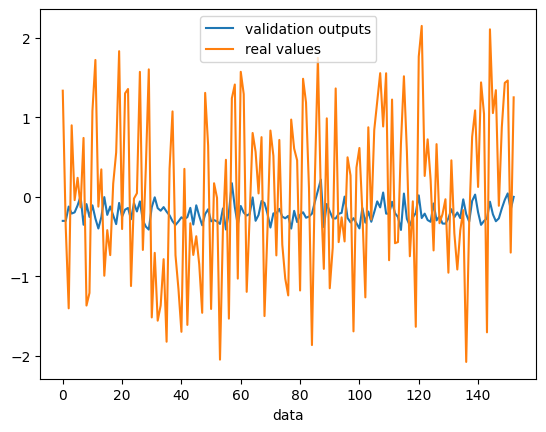

Epoch 1/200: train loss = 1.0442664623260498 , validation loss = 1.0968116521835327


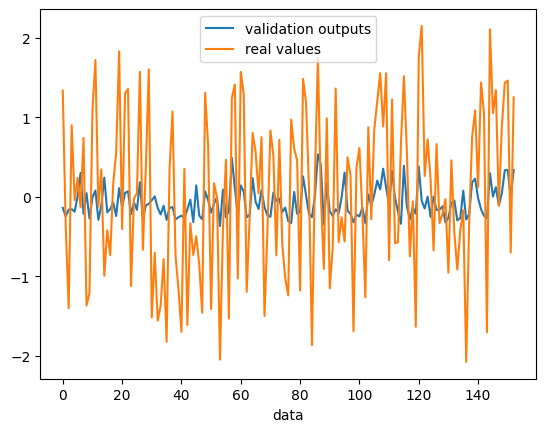

Epoch 6/200: train loss = 0.847214937210083 , validation loss = 0.8868701457977295


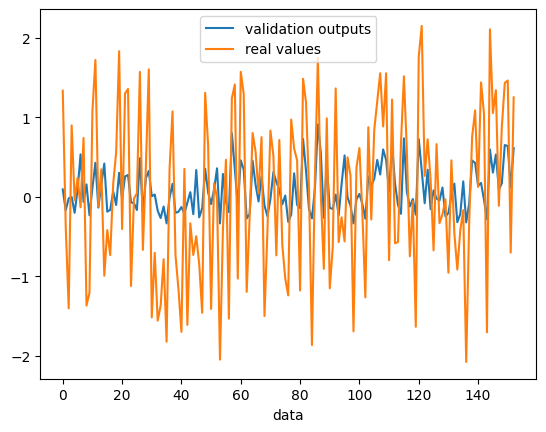

Epoch 11/200: train loss = 0.698316752910614 , validation loss = 0.7365298867225647


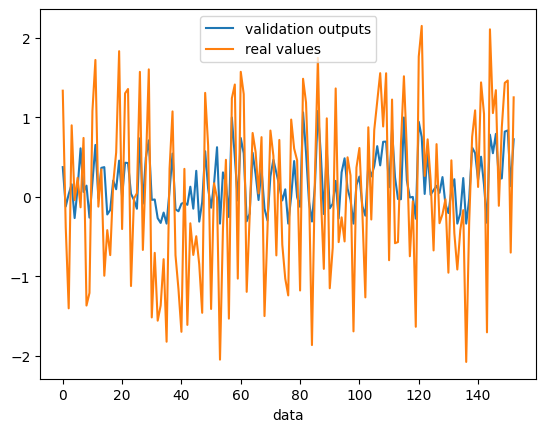

Epoch 16/200: train loss = 0.5955432653427124 , validation loss = 0.6236646175384521


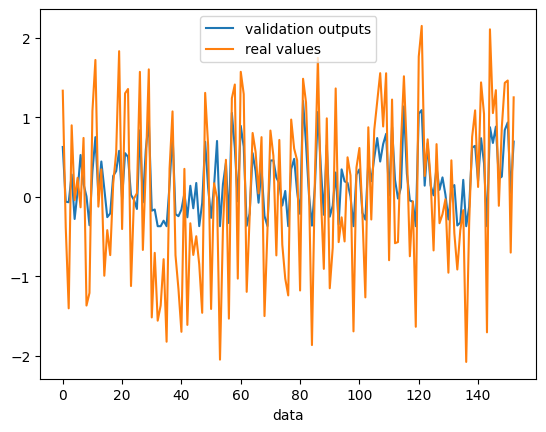

Epoch 21/200: train loss = 0.49857616424560547 , validation loss = 0.51382976770401


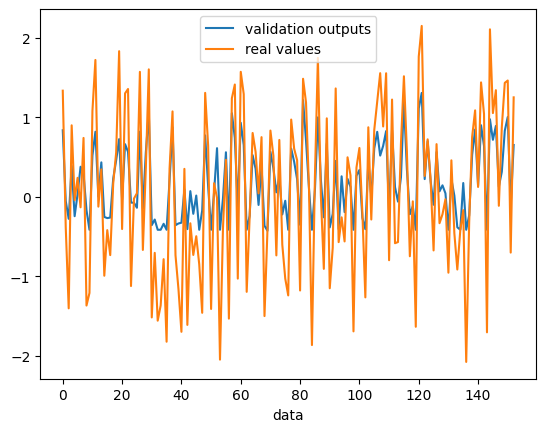

Epoch 26/200: train loss = 0.40321534872055054 , validation loss = 0.4089454710483551


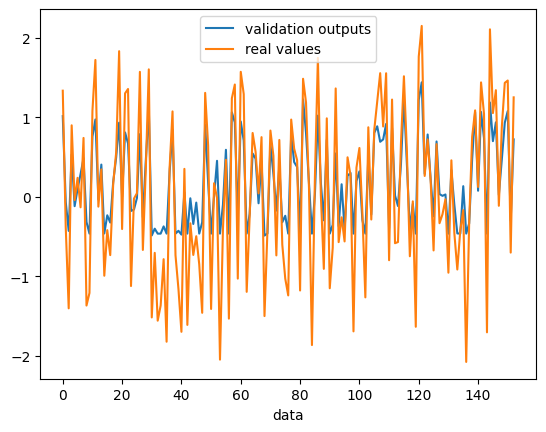

Epoch 31/200: train loss = 0.32175639271736145 , validation loss = 0.32135117053985596


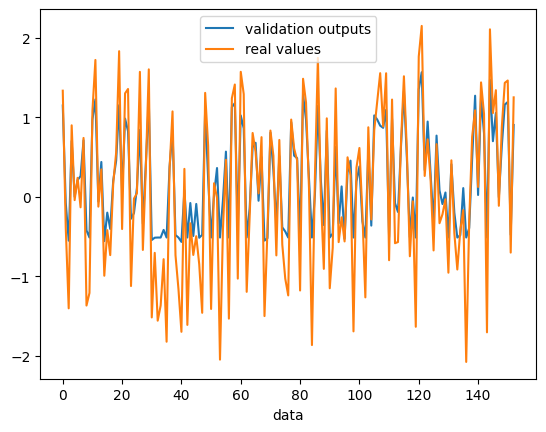

Epoch 36/200: train loss = 0.2576216757297516 , validation loss = 0.2543075680732727


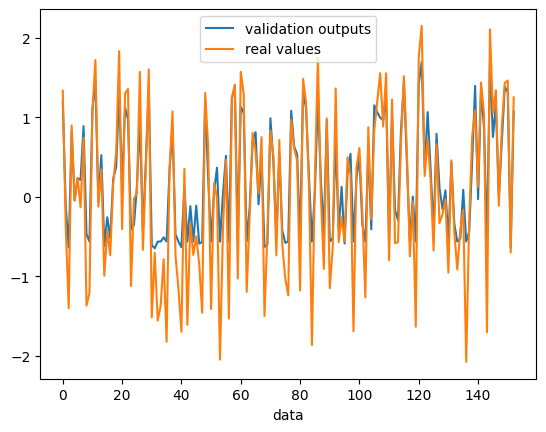

Epoch 41/200: train loss = 0.2124054878950119 , validation loss = 0.21219319105148315


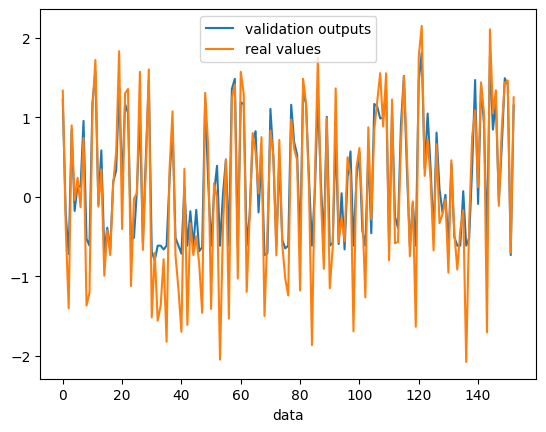

Epoch 46/200: train loss = 0.18096867203712463 , validation loss = 0.18605615198612213


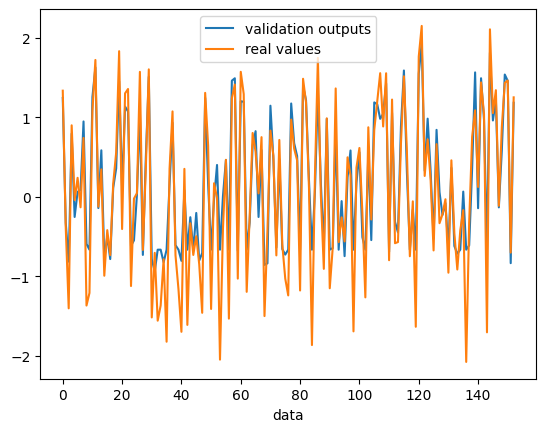

Epoch 51/200: train loss = 0.15774309635162354 , validation loss = 0.16694873571395874


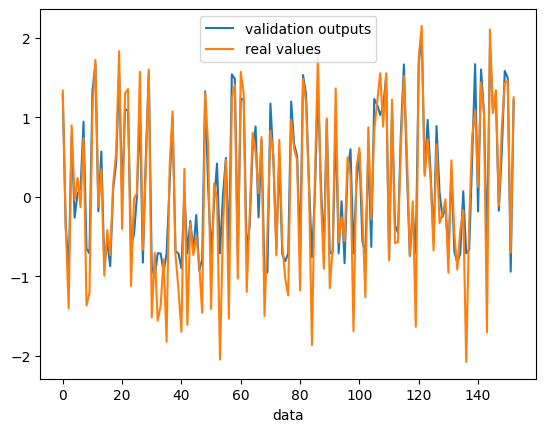

Epoch 56/200: train loss = 0.13991135358810425 , validation loss = 0.15143458545207977


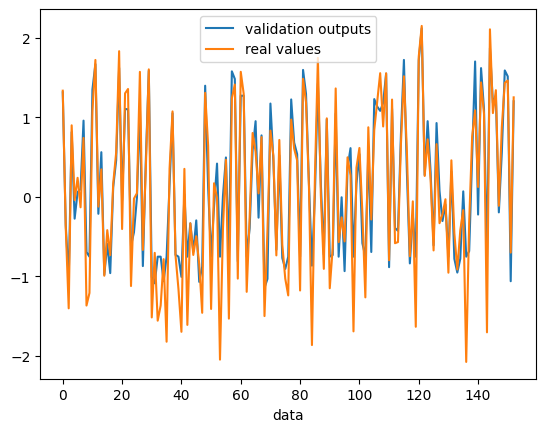

Epoch 61/200: train loss = 0.12577426433563232 , validation loss = 0.14091166853904724


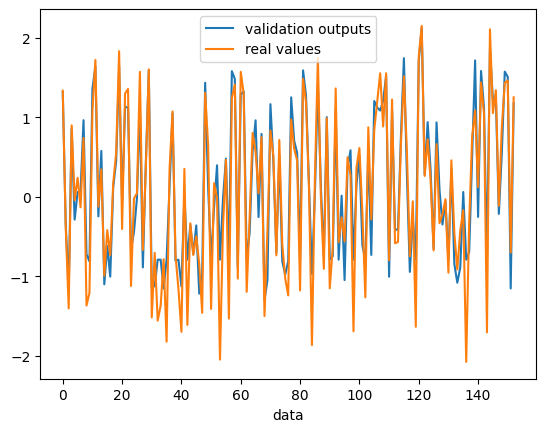

Epoch 66/200: train loss = 0.11317096650600433 , validation loss = 0.1333846002817154


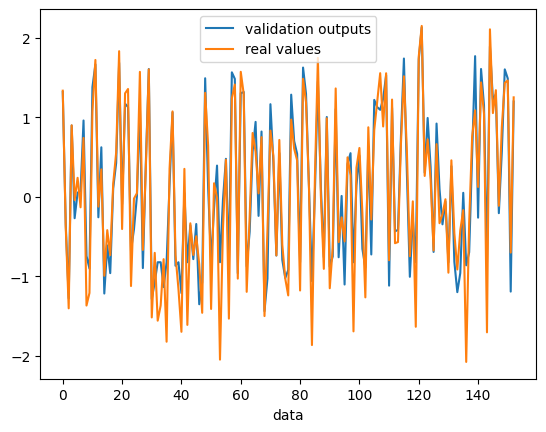

Epoch 71/200: train loss = 0.10123839974403381 , validation loss = 0.12393295764923096


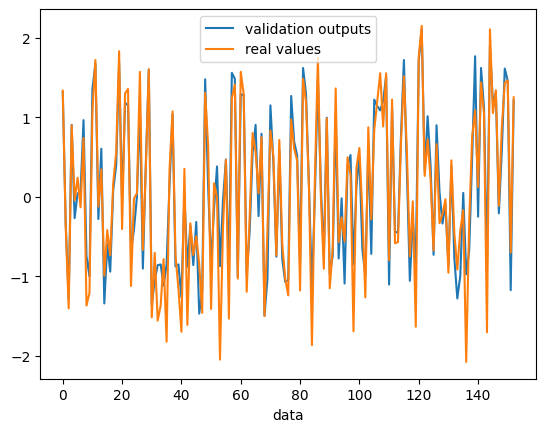

Epoch 76/200: train loss = 0.08973388373851776 , validation loss = 0.11398708075284958


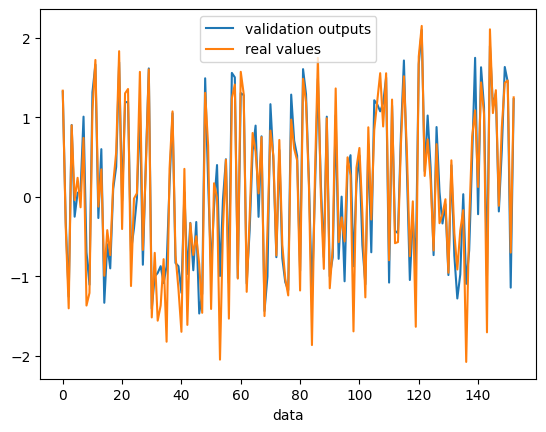

Epoch 81/200: train loss = 0.0786956325173378 , validation loss = 0.10111340880393982


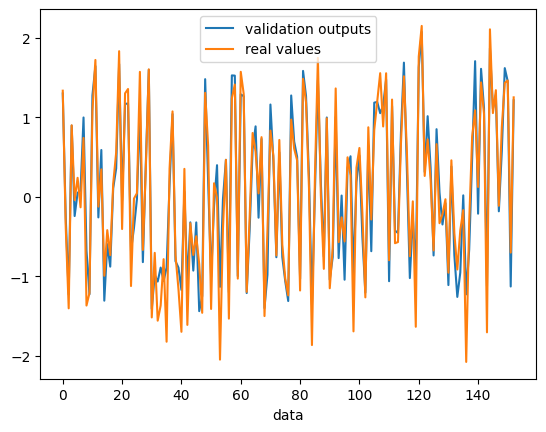

Epoch 86/200: train loss = 0.06877773255109787 , validation loss = 0.08864162862300873


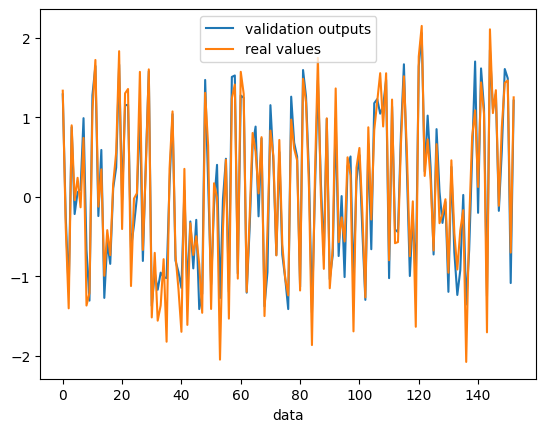

Epoch 91/200: train loss = 0.061065830290317535 , validation loss = 0.07638794928789139


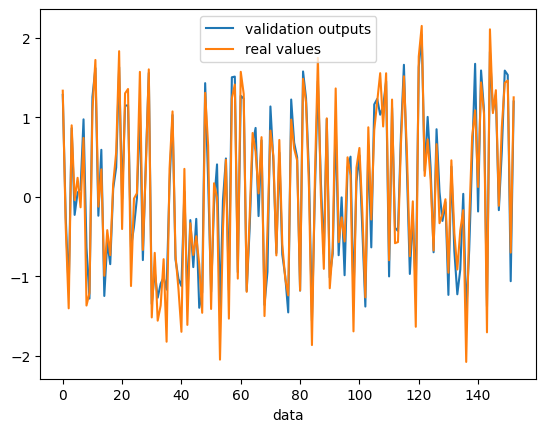

Epoch 96/200: train loss = 0.05627751722931862 , validation loss = 0.06779487431049347


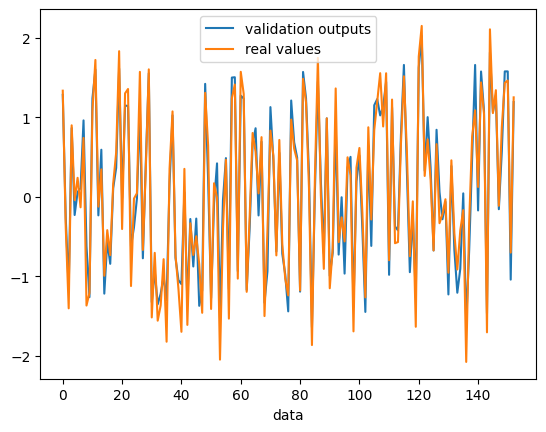

Epoch 101/200: train loss = 0.053751155734062195 , validation loss = 0.06208161264657974


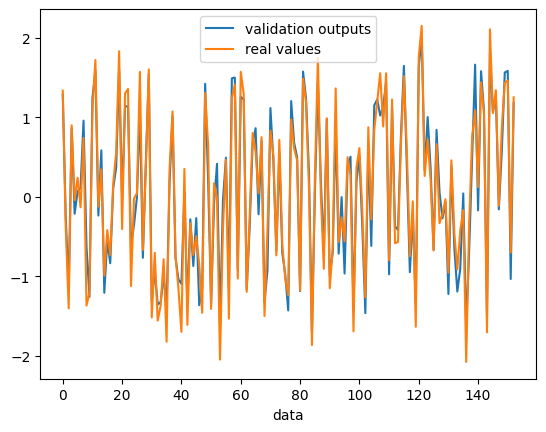

Epoch 106/200: train loss = 0.052549414336681366 , validation loss = 0.05904095992445946


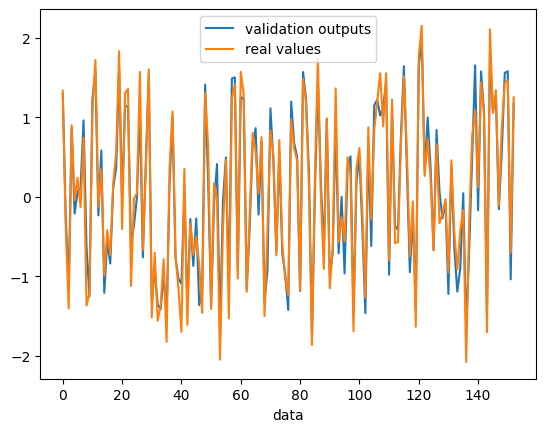

Epoch 111/200: train loss = 0.05201968178153038 , validation loss = 0.05760449171066284


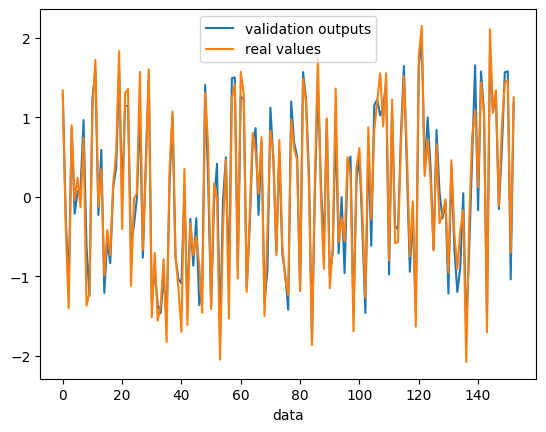

Epoch 116/200: train loss = 0.05178451165556908 , validation loss = 0.05675799027085304


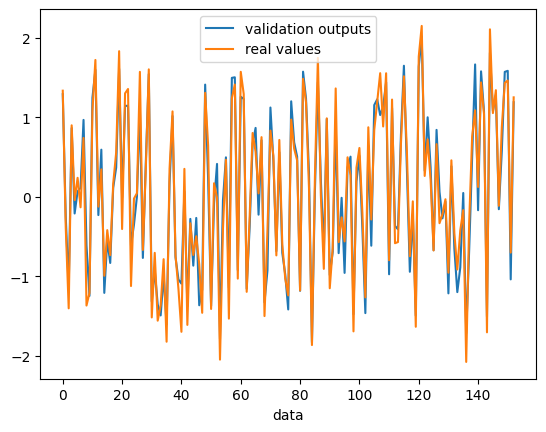

Epoch 121/200: train loss = 0.05166000500321388 , validation loss = 0.05623269081115723


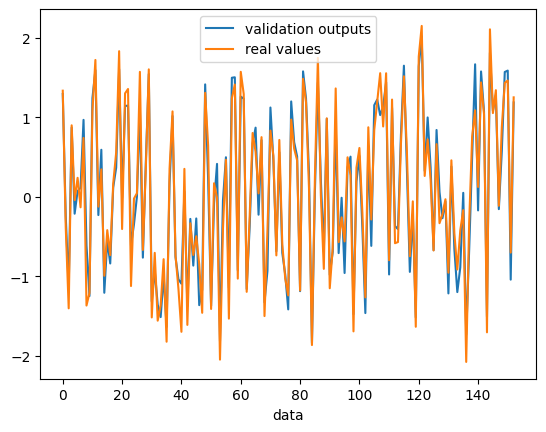

Epoch 126/200: train loss = 0.051571644842624664 , validation loss = 0.056026071310043335


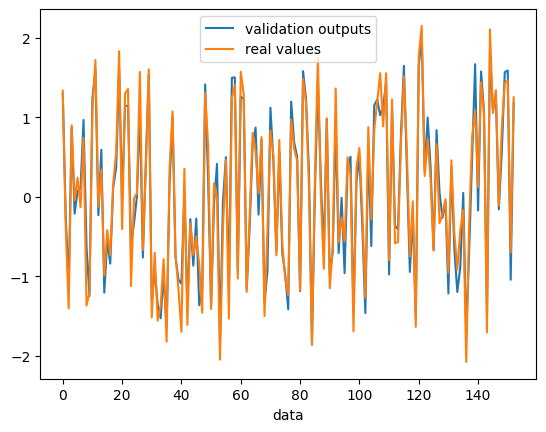

Epoch 131/200: train loss = 0.05150808021426201 , validation loss = 0.05594206228852272


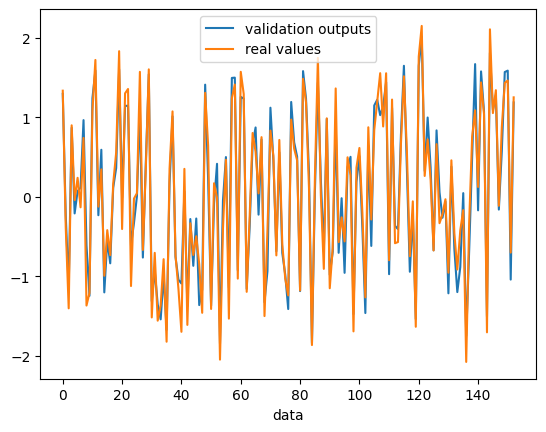

Epoch 136/200: train loss = 0.05146622285246849 , validation loss = 0.05579330027103424


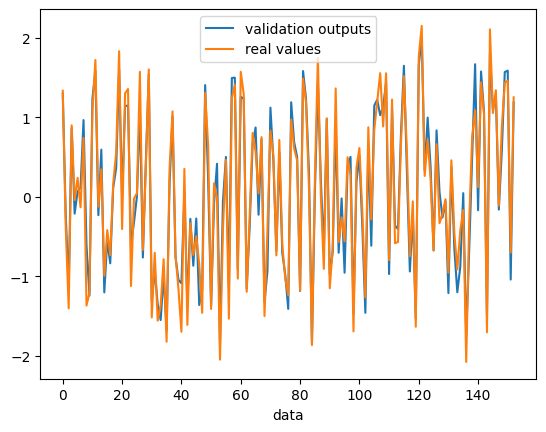

Epoch 141/200: train loss = 0.051429785788059235 , validation loss = 0.05575456842780113


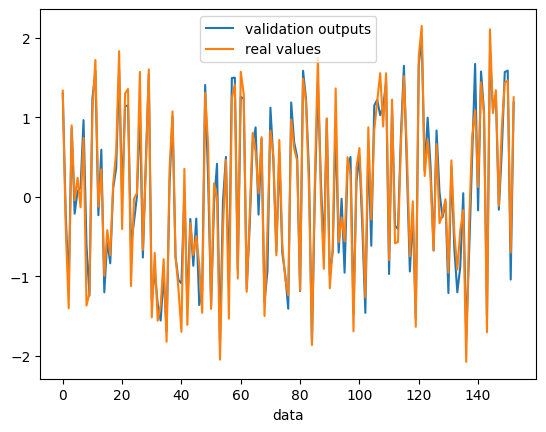

Epoch 146/200: train loss = 0.05139460414648056 , validation loss = 0.055657293647527695


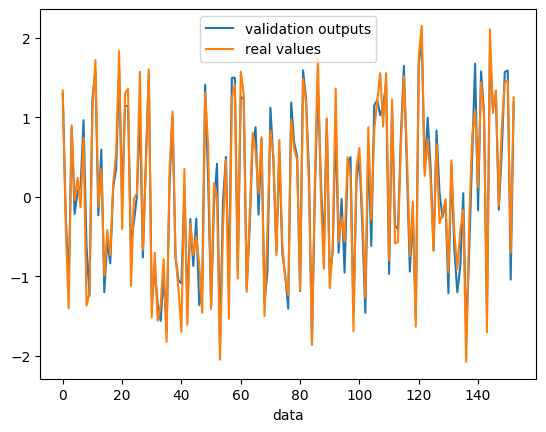

Epoch 151/200: train loss = 0.05136080086231232 , validation loss = 0.05564764887094498


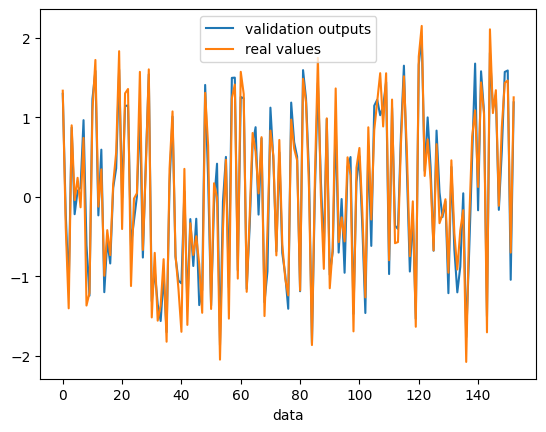

Epoch 156/200: train loss = 0.05132729187607765 , validation loss = 0.05569443106651306


In [16]:
numberOfEpochs=200
train_losses=[]
val_losses=[]
patience=10 # for early stopping
counter=0
best_val_loss=10000000

for epoch in range(numberOfEpochs):

    model.train()
    optimizer.zero_grad()
    outputs=model(x_train)

    loss=criterion(outputs,y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    #validation
    model.eval()
    with torch.no_grad():
        val_outputs=model(x_val)
        
        val_loss=criterion(val_outputs,y_val)
        if val_loss < best_val_loss:
            best_val_loss=val_loss
            counter=0
        else:
            counter+=1
        if counter == patience: # early stopping
            break
        val_losses.append(val_loss.item())
        if epoch % 5 == 0:
            plt.plot(val_outputs,label='validation outputs')
            plt.plot(y_val,label='real values')
            plt.xlabel('data')
            plt.ylabel('')
            plt.legend()
            plt.show()

    if epoch % 5 == 0:
        print(f'Epoch {epoch+1}/{numberOfEpochs}: train loss = {loss.item()} , validation loss = {val_loss.item()}')

### drawing chart of costs

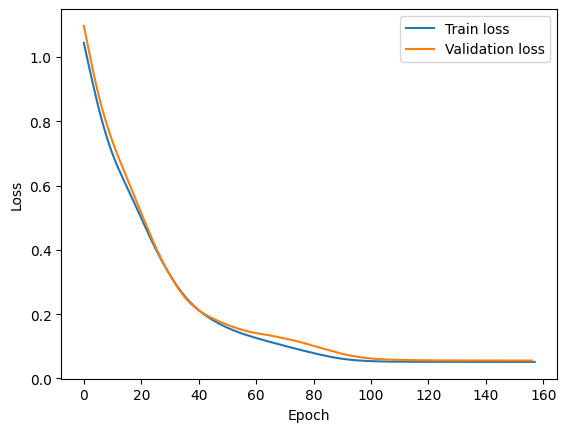

In [17]:
plt.plot(train_losses,label='Train loss')
plt.plot(val_losses,label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



### model evaluation on test data

R^2 score is: 0.9429685790349576


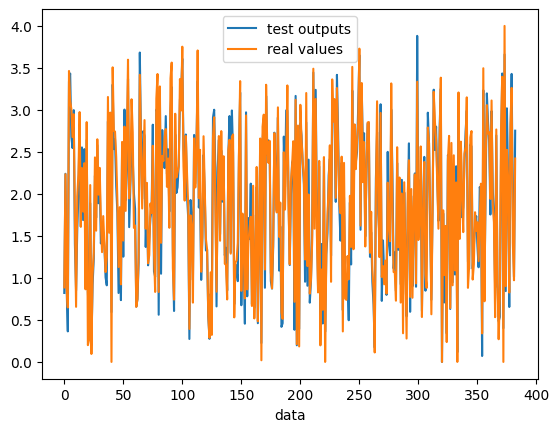

R^2 score is: 0.9482548236846924


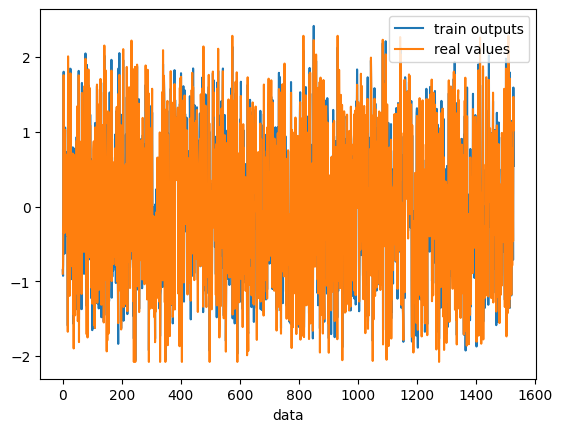

In [18]:
model.eval()
with torch.no_grad():
    predictions1=model(test_input)

    # because we normalize the outputs(GPAs),we need to convert them to the range 0 - 4
    predictions1=scaler.inverse_transform(predictions1) 
    test_output=scaler.inverse_transform(test_output) 
    
    # clip predictions between 0 - 4
    predictions1=torch.clamp(torch.tensor(predictions1),min=0,max=4)

    # calculate r^2 score
    r2_1=r2_score(test_output,predictions1.numpy())
    print(f'R^2 score is: {r2_1}')
    
    plt.plot(predictions1,label='test outputs')
    plt.plot(test_output,label='real values')
    plt.xlabel('data')
    plt.ylabel('')
    plt.legend()
    plt.show()

model.eval()
with torch.no_grad():
    predictions2=model(train_input)
    r2_2=r2_score(train_output.numpy(),predictions2.numpy())
    print(f'R^2 score is: {r2_2}')

    plt.plot(predictions2,label='train outputs')
    plt.plot(train_output,label='real values')
    plt.xlabel('data')
    plt.ylabel('')
    plt.legend()
    plt.show()

In [19]:

print(f'predictions are between: {min(predictions1.numpy())} - ,{max(predictions1.numpy())}')


predictions are between: [0.] - ,[3.88144619]
